In [ ]:
pip install pandas numpy matplotlib plotly streamlit scikit-learn prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 80.6 MB/s eta 0:00:00


In [3]:
import pandas as pd

df = pd.read_csv('/content/HHS_Unaccompanied_Alien_Children_Program.csv')

In [4]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [5]:
!pip install pandas numpy matplotlib plotly prophet

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [7]:
df = pd.read_csv('/content/HHS_Unaccompanied_Alien_Children_Program.csv')

In [8]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [9]:
df.columns

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
df.isnull().sum()

,0
Date,450
Children apprehended and placed in CBP custody*,450
Children in CBP custody,450
Children transferred out of CBP custody,450
Children in HHS Care,450
Children discharged from HHS Care,450


In [13]:
df = df.fillna(0)

In [14]:
df.columns = [
    'date',
    'cbp_apprehended',
    'cbp_custody',
    'cbp_transferred',
    'hhs_care',
    'hhs_discharged'
]

In [15]:
df['transfer_efficiency'] = (
    df['cbp_transferred'] /
    df['cbp_custody']
)

In [17]:
cols = [
    'cbp_apprehended',
    'cbp_custody',
    'cbp_transferred',
    'hhs_care',
    'hhs_discharged'
]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '')
    )

    df[col] = pd.to_numeric(df[col])

In [18]:
df['throughput_rate'] = (
    df['hhs_discharged'] /
    df['cbp_apprehended']
)

In [19]:
df['backlog_rate'] = (
    df['cbp_apprehended'] -
    df['hhs_discharged']
)

In [20]:
df.head()

,date,cbp_apprehended,cbp_custody,cbp_transferred,hhs_care,hhs_discharged,transfer_efficiency,throughput_rate,backlog_rate
0,2025-12-21 00:00:00,6.0,18.0,11.0,2484,14.0,0.611111,2.333333,-8.0
1,2025-12-18 00:00:00,11.0,50.0,6.0,2472,16.0,0.120000,1.454545,-5.0
2,2025-12-17 00:00:00,7.0,31.0,11.0,2481,10.0,0.354839,1.428571,-3.0
3,2025-12-16 00:00:00,8.0,54.0,15.0,2468,9.0,0.277778,1.125000,-1.0
4,2025-12-15 00:00:00,11.0,42.0,9.0,2470,7.0,0.214286,0.636364,4.0


In [21]:
fig = px.line(
    df,
    x='date',
    y=[
        'cbp_apprehended',
        'cbp_transferred',
        'hhs_discharged'
    ],
    title='Daily Pipeline Movement'
)

fig.show()

In [22]:
fig = px.line(
    df,
    x='date',
    y='transfer_efficiency',
    title='Transfer Efficiency Over Time'
)

fig.show()

In [24]:
df.columns

Index(['date', 'cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_care',
       'hhs_discharged', 'transfer_efficiency', 'throughput_rate',
       'backlog_rate'],
      dtype='object')

In [25]:
df['discharge_effectiveness'] = (
    df['hhs_discharged'] / df['hhs_care']
)

In [26]:
df[['hhs_discharged','hhs_care','discharge_effectiveness']].head()

,hhs_discharged,hhs_care,discharge_effectiveness
0,14.0,2484,0.005636
1,16.0,2472,0.006472
2,10.0,2481,0.004031
3,9.0,2468,0.003647
4,7.0,2470,0.002834


In [27]:
import plotly.express as px

fig = px.line(
    df,
    x='date',
    y='discharge_effectiveness',
    title='Discharge Effectiveness Over Time'
)

fig.show()

In [28]:
fig = px.bar(
    df,
    x='date',
    y='backlog_rate',
    title='Backlog Accumulation'
)

fig.show()

In [29]:
df['rolling_transfer'] = (
    df['transfer_efficiency']
    .rolling(7)
    .mean()
)

In [30]:
fig = px.line(
    df,
    x='date',
    y='rolling_transfer',
    title='7-Day Rolling Transfer Efficiency'
)

fig.show()

In [31]:
df['transfer_bottleneck'] = (
    (df['cbp_custody'] > df['cbp_custody'].mean()) &
    (df['transfer_efficiency'] < 0.5)
)

In [32]:
df[df['transfer_bottleneck'] == True]

,date,cbp_apprehended,cbp_custody,cbp_transferred,hhs_care,hhs_discharged,transfer_efficiency,throughput_rate,backlog_rate,discharge_effectiveness,rolling_transfer,transfer_bottleneck
246,2024-12-19 00:00:00,269.0,412.0,204.0,6600,238.0,0.495146,0.884758,31.0,0.036061,0.848053,True
254,2024-12-09 00:00:00,224.0,315.0,152.0,6268,174.0,0.482540,0.776786,50.0,0.027760,0.718391,True
310,2024-09-17 00:00:00,159.0,304.0,139.0,6227,160.0,0.457237,1.006289,-1.0,0.025695,0.788626,True
348,2024-07-23 00:00:00,120.0,257.0,126.0,5965,170.0,0.490272,1.416667,-50.0,0.028500,0.789898,True
381,2024-06-04 00:00:00,260.0,356.0,176.0,7565,203.0,0.494382,0.780769,57.0,0.026834,0.732765,True
385,2024-05-29 00:00:00,182.0,462.0,158.0,7491,141.0,0.341991,0.774725,41.0,0.018823,0.772699,True
405,2024-04-30 00:00:00,220.0,443.0,194.0,7431,135.0,0.437923,0.613636,85.0,0.018167,0.637208,True
439,2024-03-13 00:00:00,165.0,358.0,167.0,8819,239.0,0.466480,1.448485,-74.0,0.027101,0.834627,True
461,2024-02-11 00:00:00,205.0,515.0,226.0,8056,347.0,0.438835,1.692683,-142.0,0.043073,0.766074,True
466,2024-02-04 00:00:00,253.0,531.0,248.0,7813,342.0,0.467043,1.351779,-89.0,0.043773,0.689326,True


In [35]:
df['date'].dtype

dtype('O')

In [36]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [37]:
df['date'].dtype

dtype('<M8[ns]')

In [38]:
df['month'] = df['date'].dt.to_period('M')

In [39]:
monthly = df.groupby('month')[['cbp_apprehended', 'hhs_discharged']].sum()
monthly

,cbp_apprehended,hhs_discharged
month,,
1970-01,0.0,0.0
2023-01,247.0,1856.0
2023-02,1886.0,5183.0
2023-03,2479.0,5375.0
2023-04,3129.0,5668.0
2023-05,2746.0,6256.0
2023-06,1774.0,4029.0
2023-07,2858.0,4407.0
2023-08,2751.0,6470.0


In [40]:
df['month'] = df['date'].dt.to_period('M')

monthly = df.groupby('month')[
    ['cbp_apprehended','hhs_discharged']
].sum()

monthly

,cbp_apprehended,hhs_discharged
month,,
1970-01,0.0,0.0
2023-01,247.0,1856.0
2023-02,1886.0,5183.0
2023-03,2479.0,5375.0
2023-04,3129.0,5668.0
2023-05,2746.0,6256.0
2023-06,1774.0,4029.0
2023-07,2858.0,4407.0
2023-08,2751.0,6470.0


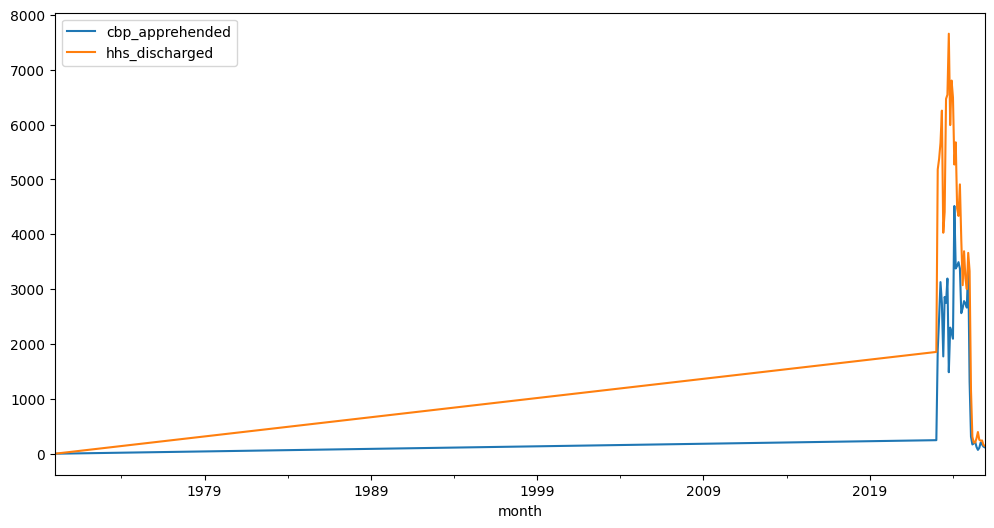

In [41]:
monthly.plot(figsize=(12,6))
plt.show()

In [42]:
df.to_csv('cleaned_uac_dataset.csv', index=False)